# FIS-Based Spatially Variable DoD Uncertainty v1

This notebook applies a rule-based Mamdani fuzzy inference system to estimate spatially variable DEM vertical uncertainty and filter a DEM of Difference (DoD) by a 95% confidence threshold.

This is not a trained ML model. It is a rule-based uncertainty filter using:

- slope in degrees
- LiDAR point density in pts/m2
- canopy cover percentage

The v1 paths are centralized below and point to the Thomas data directory plus the `fis_inputs` directory created by `FIS_setting_slope_density_vege_v1.ipynb`.


In [1]:
from pathlib import Path

import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

BASE_DIR = Path("/mnt/c/Users/amehedi/Downloads/thomas")
FIS_INPUT_DIR = BASE_DIR / "fis_inputs"
OUT_DIR = BASE_DIR / "fis_dod_uncertainty_v1"
PLOT_DIR = OUT_DIR / "plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

DEM_POST_PATH = BASE_DIR / "dem_post.tif"
DEM_PRE_PATH = BASE_DIR / "dem_pre.tif"

# Preferred DoD. If this file is missing, the notebook falls back to DEM_post - DEM_pre.
DOD_PATH = BASE_DIR / "dem_diff_updated.tif"
USE_DOD_RASTER = True

SLOPE_POST_PATH = FIS_INPUT_DIR / "slope_10m_post.tif"
SLOPE_PRE_PATH = FIS_INPUT_DIR / "slope_10m_pre.tif"
POINT_DENSITY_PATH = FIS_INPUT_DIR / "point_density_10m.tif"
CANOPY_PATH = FIS_INPUT_DIR / "canopy_2019_10m.tif"

UNCERTAINTY_POST_PATH = OUT_DIR / "uncertainty_dem_post.tif"
UNCERTAINTY_PRE_PATH = OUT_DIR / "uncertainty_dem_pre.tif"
DOD_USED_PATH = OUT_DIR / "dod_used.tif"
THRESHOLD_PATH = OUT_DIR / "threshold_surface_95ci.tif"
DOD_FILTERED_PATH = OUT_DIR / "dod_filtered_fis_95ci.tif"
SIGNIFICANT_MASK_PATH = OUT_DIR / "significant_change_mask_95ci.tif"

NODATA_FLOAT = -9999.0
NODATA_UINT8 = 255
REUSE_EXISTING_UNCERTAINTY = False

for label, path in {
    "DEM post": DEM_POST_PATH,
    "DEM pre": DEM_PRE_PATH,
    "DoD raster": DOD_PATH,
    "slope post": SLOPE_POST_PATH,
    "slope pre": SLOPE_PRE_PATH,
    "point density": POINT_DENSITY_PATH,
    "canopy": CANOPY_PATH,
}.items():
    print(f"{label}: {path} exists={path.exists()}")

print("output folder:", OUT_DIR)

DEM post: /mnt/c/Users/amehedi/Downloads/thomas/dem_post.tif exists=True
DEM pre: /mnt/c/Users/amehedi/Downloads/thomas/dem_pre.tif exists=True
DoD raster: /mnt/c/Users/amehedi/Downloads/thomas/dem_diff_updated.tif exists=True
slope post: /mnt/c/Users/amehedi/Downloads/thomas/fis_inputs/slope_10m_post.tif exists=True
slope pre: /mnt/c/Users/amehedi/Downloads/thomas/fis_inputs/slope_10m_pre.tif exists=True
point density: /mnt/c/Users/amehedi/Downloads/thomas/fis_inputs/point_density_10m.tif exists=True
canopy: /mnt/c/Users/amehedi/Downloads/thomas/fis_inputs/canopy_2019_10m.tif exists=True
output folder: /mnt/c/Users/amehedi/Downloads/thomas/fis_dod_uncertainty_v1


## 1. Build The FIS

The point-density `high` membership is trapezoidal in v1 so a QL2 value of `1.0 pts/m2` is treated as high density, consistent with the notebook comments. The membership and centroid operations are implemented directly with NumPy, so this notebook does not require scikit-fuzzy.


In [2]:
def trimf(x, abc):
    a, b, c = map(float, abc)
    x = np.asarray(x, dtype="float64")
    y = np.zeros_like(x, dtype="float64")

    if b != a:
        left = (a < x) & (x < b)
        y[left] = (x[left] - a) / (b - a)
    y[x == b] = 1.0

    if c != b:
        right = (b < x) & (x < c)
        y[right] = (c - x[right]) / (c - b)

    if a == b:
        y[x <= b] = 1.0
    if b == c:
        y[x >= b] = 1.0

    return np.clip(y, 0.0, 1.0)


def trapmf(x, abcd):
    a, b, c, d = map(float, abcd)
    x = np.asarray(x, dtype="float64")
    y = np.zeros_like(x, dtype="float64")

    if b != a:
        rising = (a < x) & (x < b)
        y[rising] = (x[rising] - a) / (b - a)
    else:
        y[x <= b] = 1.0

    plateau = (b <= x) & (x <= c)
    y[plateau] = 1.0

    if d != c:
        falling = (c < x) & (x < d)
        y[falling] = (d - x[falling]) / (d - c)
    else:
        y[x >= c] = 1.0

    return np.clip(y, 0.0, 1.0)


def interp_membership(x, mf, value):
    return float(np.interp(float(value), x, mf, left=mf[0], right=mf[-1]))


def integrate_trapezoid(y, x):
    if hasattr(np, "trapezoid"):
        return np.trapezoid(y, x)
    return np.trapz(y, x)


def defuzz_centroid(x, mf):
    total = integrate_trapezoid(mf, x)
    if total <= 0 or not np.isfinite(total):
        return np.nan
    return float(integrate_trapezoid(x * mf, x) / total)


def build_fis():
    slope_range = np.arange(0, 91, 0.1)       # degrees
    density_range = np.arange(0, 5.1, 0.01)   # pts/m2
    canopy_range = np.arange(0, 101, 0.1)     # percent
    dz_range = np.arange(0, 1.01, 0.001)      # metres

    slope_lo = trimf(slope_range, [0, 0, 15])
    slope_md = trimf(slope_range, [5, 25, 45])
    slope_hi = trimf(slope_range, [30, 90, 90])

    density_lo = trapmf(density_range, [0, 0, 0.25, 0.6])
    density_md = trimf(density_range, [0.3, 0.8, 1.5])
    density_hi = trapmf(density_range, [0.8, 1.0, 5.0, 5.0])

    canopy_lo = trimf(canopy_range, [0, 0, 25])
    canopy_md = trimf(canopy_range, [10, 40, 70])
    canopy_hi = trimf(canopy_range, [50, 100, 100])

    dz_low = trimf(dz_range, [0.00, 0.05, 0.10])
    dz_avg = trimf(dz_range, [0.05, 0.10, 0.20])
    dz_high = trimf(dz_range, [0.10, 0.20, 0.35])
    dz_extreme = trimf(dz_range, [0.25, 0.50, 1.00])

    return {
        "slope_range": slope_range,
        "density_range": density_range,
        "canopy_range": canopy_range,
        "dz_range": dz_range,
        "slope": (slope_lo, slope_md, slope_hi),
        "density": (density_lo, density_md, density_hi),
        "canopy": (canopy_lo, canopy_md, canopy_hi),
        "dz": (dz_low, dz_avg, dz_high, dz_extreme),
    }


def apply_fis_rules(slope_val, density_val, canopy_val, fis):
    sr = fis["slope_range"]
    dr = fis["density_range"]
    cr = fis["canopy_range"]
    dzr = fis["dz_range"]

    s_lo, s_md, s_hi = fis["slope"]
    d_lo, d_md, d_hi = fis["density"]
    c_lo, c_md, c_hi = fis["canopy"]
    dz_low, dz_avg, dz_high, dz_ext = fis["dz"]

    slope_val = np.clip(slope_val, 0, 90)
    density_val = np.clip(density_val, 0, 5)
    canopy_val = np.clip(canopy_val, 0, 100)

    s = [
        interp_membership(sr, s_lo, slope_val),
        interp_membership(sr, s_md, slope_val),
        interp_membership(sr, s_hi, slope_val),
    ]
    d = [
        interp_membership(dr, d_lo, density_val),
        interp_membership(dr, d_md, density_val),
        interp_membership(dr, d_hi, density_val),
    ]
    c = [
        interp_membership(cr, c_lo, canopy_val),
        interp_membership(cr, c_md, canopy_val),
        interp_membership(cr, c_hi, canopy_val),
    ]

    rules = [
        (0, 2, 0, dz_low),
        (0, 2, 1, dz_avg),
        (0, 2, 2, dz_avg),
        (0, 1, 0, dz_avg),
        (0, 1, 2, dz_high),
        (0, 0, 0, dz_avg),
        (0, 0, 2, dz_high),
        (1, 2, 0, dz_avg),
        (1, 2, 2, dz_high),
        (1, 1, 1, dz_high),
        (1, 0, 2, dz_ext),
        (2, 2, 0, dz_high),
        (2, 2, 2, dz_ext),
        (2, 1, 1, dz_ext),
        (2, 0, 0, dz_high),
        (2, 0, 2, dz_ext),
    ]

    aggregated = np.zeros_like(dzr)
    for si, di, ci, out_mf in rules:
        firing = min(s[si], d[di], c[ci])
        if firing > 0:
            aggregated = np.maximum(aggregated, np.minimum(firing, out_mf))

    if aggregated.sum() == 0:
        return 0.10
    value = defuzz_centroid(dzr, aggregated)
    if not np.isfinite(value):
        return 0.10
    return value


fis = build_fis()
print("FIS built")


FIS built


## 2. Raster Helpers


In [3]:
def read_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1).astype("float32")
        profile = src.profile.copy()
        nodata = src.nodata

    invalid = ~np.isfinite(data)
    if nodata is not None:
        invalid |= np.isclose(data, nodata)
    data[invalid] = np.nan
    return data, profile


def load_and_align(src_path, ref_profile, ref_shape, resampling=Resampling.bilinear):
    with rasterio.open(src_path) as src:
        same_shape = src.shape == ref_shape
        same_crs = src.crs == ref_profile["crs"]
        same_transform = src.transform.almost_equals(ref_profile["transform"])

        if same_shape and same_crs and same_transform:
            data = src.read(1).astype("float32")
        else:
            data = np.full(ref_shape, np.nan, dtype="float32")
            reproject(
                source=rasterio.band(src, 1),
                destination=data,
                src_transform=src.transform,
                src_crs=src.crs,
                src_nodata=src.nodata,
                dst_transform=ref_profile["transform"],
                dst_crs=ref_profile["crs"],
                dst_nodata=np.nan,
                resampling=resampling,
            )

        nodata = src.nodata

    invalid = ~np.isfinite(data)
    if nodata is not None:
        invalid |= np.isclose(data, nodata)
    data[invalid] = np.nan
    return data


def write_float_raster(path, array, profile, nodata=NODATA_FLOAT):
    data = np.asarray(array, dtype="float32")
    out = np.where(np.isfinite(data), data, nodata).astype("float32")

    meta = profile.copy()
    meta.update(driver="GTiff", dtype="float32", count=1, nodata=nodata, compress="deflate")
    if not meta.get("tiled", False):
        meta.pop("blockxsize", None)
        meta.pop("blockysize", None)

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(path, "w", **meta) as dst:
        dst.write(out, 1)
    return path


def write_uint8_raster(path, array, profile, nodata=NODATA_UINT8):
    data = np.asarray(array, dtype="uint8")
    meta = profile.copy()
    meta.update(driver="GTiff", dtype="uint8", count=1, nodata=nodata, compress="deflate")
    if not meta.get("tiled", False):
        meta.pop("blockxsize", None)
        meta.pop("blockysize", None)

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(path, "w", **meta) as dst:
        dst.write(data, 1)
    return path


## 3. Load Inputs


In [4]:
dem_post, profile = read_raster(DEM_POST_PATH)
dem_pre = load_and_align(DEM_PRE_PATH, profile, dem_post.shape)
slope_post = load_and_align(SLOPE_POST_PATH, profile, dem_post.shape)
slope_pre = load_and_align(SLOPE_PRE_PATH, profile, dem_post.shape)
point_density = load_and_align(POINT_DENSITY_PATH, profile, dem_post.shape)
canopy = load_and_align(CANOPY_PATH, profile, dem_post.shape)

valid_dem = np.isfinite(dem_post) & np.isfinite(dem_pre)

slope_post = np.nan_to_num(slope_post, nan=0.0)
slope_pre = np.nan_to_num(slope_pre, nan=0.0)
point_density = np.nan_to_num(point_density, nan=1.0)
canopy = np.nan_to_num(canopy, nan=0.0)

print("shape:", dem_post.shape)
print("valid DEM pixels:", int(valid_dem.sum()))
print("slope post min/max:", float(np.nanmin(slope_post)), float(np.nanmax(slope_post)))
print("slope pre min/max:", float(np.nanmin(slope_pre)), float(np.nanmax(slope_pre)))
print("density min/max:", float(np.nanmin(point_density)), float(np.nanmax(point_density)))
print("canopy min/max:", float(np.nanmin(canopy)), float(np.nanmax(canopy)))


shape: (835, 716)
valid DEM pixels: 529116
slope post min/max: 0.0 63.32152557373047
slope pre min/max: 0.0 62.51799392700195
density min/max: 1.0 1.0
canopy min/max: 0.0 89.6342544555664


## 4. Apply FIS Pixel By Pixel

This can take several minutes for a full 10 m grid.


In [ ]:
def compute_uncertainty_surface(slope, density, canopy, valid_mask, fis):
    uncertainty = np.full(slope.shape, np.nan, dtype="float32")
    valid_idx = np.argwhere(valid_mask)

    for row, col in tqdm(valid_idx, desc="FIS pixels"):
        uncertainty[row, col] = apply_fis_rules(
            float(slope[row, col]),
            float(density[row, col]),
            float(canopy[row, col]),
            fis,
        )

    return uncertainty


if REUSE_EXISTING_UNCERTAINTY and UNCERTAINTY_POST_PATH.exists() and UNCERTAINTY_PRE_PATH.exists():
    uncertainty_post, _ = read_raster(UNCERTAINTY_POST_PATH)
    uncertainty_pre, _ = read_raster(UNCERTAINTY_PRE_PATH)
    print("reused existing uncertainty rasters")
else:
    uncertainty_post = compute_uncertainty_surface(slope_post, point_density, canopy, valid_dem, fis)
    uncertainty_pre = compute_uncertainty_surface(slope_pre, point_density, canopy, valid_dem, fis)

print("uncertainty post mean/max:", float(np.nanmean(uncertainty_post)), float(np.nanmax(uncertainty_post)))
print("uncertainty pre mean/max:", float(np.nanmean(uncertainty_pre)), float(np.nanmax(uncertainty_pre)))

FIS pixels:   0%|          | 0/529116 [00:00<?, ?it/s]

FIS pixels:   0%|          | 0/529116 [00:00<?, ?it/s]

uncertainty post mean/max: 0.23033423721790314 0.610119640827179
uncertainty pre mean/max: 0.22932113707065582 0.6101193428039551


## 5. Propagate Uncertainty And Filter DoD

The 95% confidence threshold is:

`threshold = 1.96 * sqrt(uncertainty_post**2 + uncertainty_pre**2)`

A DoD pixel is retained only where `abs(DoD) >= threshold`.


In [6]:
if USE_DOD_RASTER and DOD_PATH.exists():
    dod_raw = load_and_align(DOD_PATH, profile, dem_post.shape)
    dod_source = str(DOD_PATH)
else:
    dod_raw = dem_post - dem_pre
    dod_source = "DEM_post - DEM_pre"

threshold_surface = 1.96 * np.sqrt(uncertainty_post**2 + uncertainty_pre**2)

valid = valid_dem & np.isfinite(dod_raw) & np.isfinite(threshold_surface)
significant = valid & (np.abs(dod_raw) >= threshold_surface)

significant_mask = np.full(dod_raw.shape, NODATA_UINT8, dtype="uint8")
significant_mask[valid] = 0
significant_mask[significant] = 1

dod_filtered = np.full(dod_raw.shape, np.nan, dtype="float32")
dod_filtered[significant] = dod_raw[significant]

print("DoD source:", dod_source)
print("valid pixels:", int(valid.sum()))
print("mean threshold:", float(np.nanmean(threshold_surface[valid])))
print("significant pixels:", int(significant.sum()), f"({100 * significant.sum() / max(valid.sum(), 1):.1f}%)")
print("masked pixels:", int((valid & ~significant).sum()))
print("retained erosion pixels:", int(np.sum(dod_filtered < 0)))
print("retained deposition pixels:", int(np.sum(dod_filtered > 0)))


DoD source: /mnt/c/Users/amehedi/Downloads/thomas/dem_diff_updated.tif
valid pixels: 528494
mean threshold: 0.6377748250961304
significant pixels: 28380 (5.4%)
masked pixels: 500114
retained erosion pixels: 22825
retained deposition pixels: 5555


## 6. Save Rasters


In [7]:
write_float_raster(UNCERTAINTY_POST_PATH, uncertainty_post, profile)
write_float_raster(UNCERTAINTY_PRE_PATH, uncertainty_pre, profile)
write_float_raster(DOD_USED_PATH, dod_raw, profile)
write_float_raster(THRESHOLD_PATH, threshold_surface, profile)
write_float_raster(DOD_FILTERED_PATH, dod_filtered, profile)
write_uint8_raster(SIGNIFICANT_MASK_PATH, significant_mask, profile)

for path in [
    UNCERTAINTY_POST_PATH,
    UNCERTAINTY_PRE_PATH,
    DOD_USED_PATH,
    THRESHOLD_PATH,
    DOD_FILTERED_PATH,
    SIGNIFICANT_MASK_PATH,
]:
    print("saved:", path)


saved: /mnt/c/Users/amehedi/Downloads/thomas/fis_dod_uncertainty_v1/uncertainty_dem_post.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/fis_dod_uncertainty_v1/uncertainty_dem_pre.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/fis_dod_uncertainty_v1/dod_used.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/fis_dod_uncertainty_v1/threshold_surface_95ci.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/fis_dod_uncertainty_v1/dod_filtered_fis_95ci.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/fis_dod_uncertainty_v1/significant_change_mask_95ci.tif


## 7. Plot Results


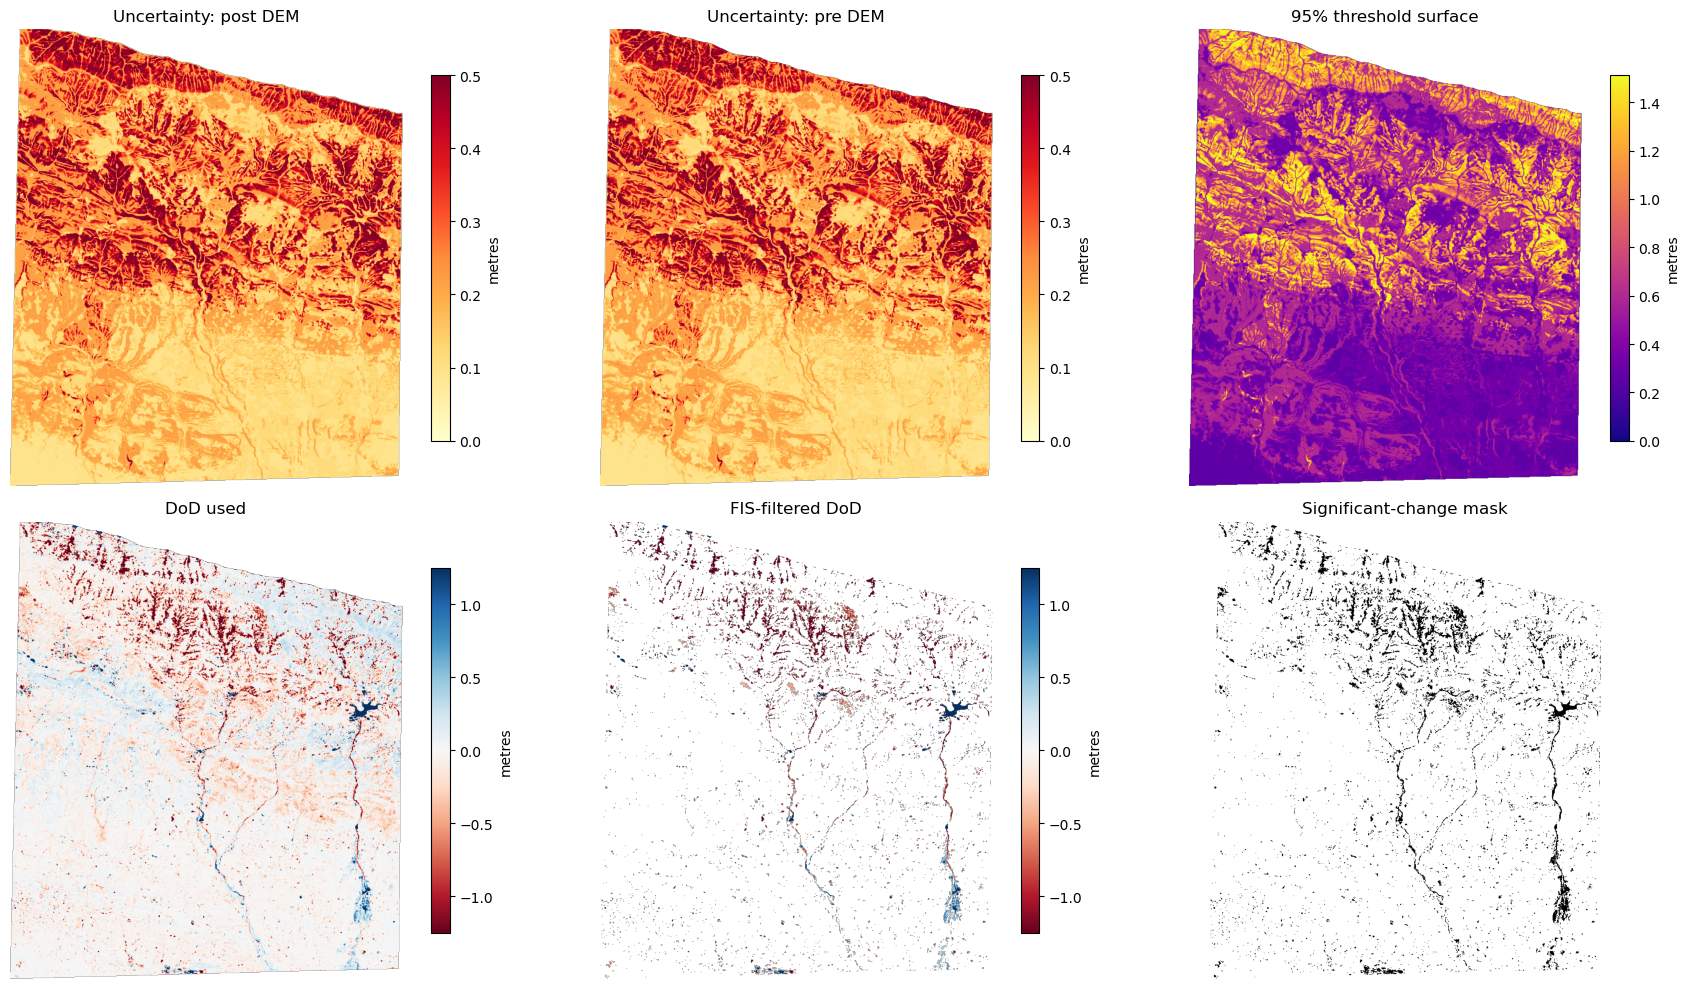

saved plot: /mnt/c/Users/amehedi/Downloads/thomas/fis_dod_uncertainty_v1/plots/dod_fis_results_v1.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

im0 = axes[0, 0].imshow(uncertainty_post, cmap="YlOrRd", vmin=0, vmax=0.5)
axes[0, 0].set_title("Uncertainty: post DEM")
plt.colorbar(im0, ax=axes[0, 0], label="metres", shrink=0.8)

im1 = axes[0, 1].imshow(uncertainty_pre, cmap="YlOrRd", vmin=0, vmax=0.5)
axes[0, 1].set_title("Uncertainty: pre DEM")
plt.colorbar(im1, ax=axes[0, 1], label="metres", shrink=0.8)

im2 = axes[0, 2].imshow(threshold_surface, cmap="plasma", vmin=0, vmax=np.nanpercentile(threshold_surface[valid], 98))
axes[0, 2].set_title("95% threshold surface")
plt.colorbar(im2, ax=axes[0, 2], label="metres", shrink=0.8)

vmax = np.nanpercentile(np.abs(dod_raw[valid]), 98)
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

im3 = axes[1, 0].imshow(dod_raw, cmap="RdBu", norm=norm)
axes[1, 0].set_title("DoD used")
plt.colorbar(im3, ax=axes[1, 0], label="metres", shrink=0.8)

im4 = axes[1, 1].imshow(dod_filtered, cmap="RdBu", norm=norm)
axes[1, 1].set_title("FIS-filtered DoD")
plt.colorbar(im4, ax=axes[1, 1], label="metres", shrink=0.8)

im5 = axes[1, 2].imshow(np.where(significant_mask == 1, 1, np.nan), cmap="gray")
axes[1, 2].set_title("Significant-change mask")

for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
plot_path = PLOT_DIR / "dod_fis_results_v1.png"
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print("saved plot:", plot_path)


## 8. Elevation Change Distribution Diagnostics


valid filtered pixels: 28380
erosion pixels: 22825 (80.4%)
deposition pixels: 5555 (19.6%)
mean: -0.6193355085439797
std: 2.6915482549020977
median: -0.7550375759601593
min/max: -15.340500831604004 31.307708740234375
skewness: 4.596749907310371
kurtosis: 37.74262333559309


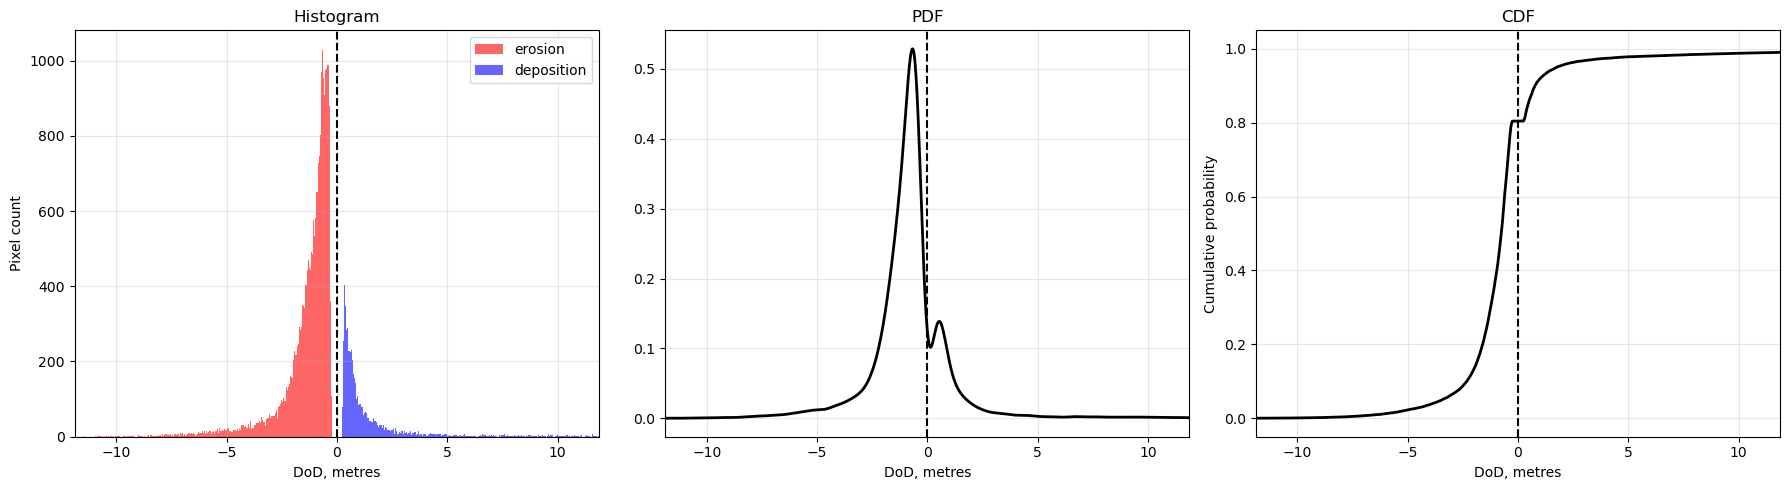

saved ECD plot: /mnt/c/Users/amehedi/Downloads/thomas/fis_dod_uncertainty_v1/plots/dod_fis_ecd_analysis_v1.png


In [9]:
from scipy import stats
from scipy.stats import gaussian_kde

values = dod_filtered[np.isfinite(dod_filtered)].astype("float64")
erosion = values[values < 0]
deposition = values[values > 0]

print("valid filtered pixels:", len(values))
if len(values) > 0:
    print("erosion pixels:", len(erosion), f"({100 * len(erosion) / len(values):.1f}%)")
    print("deposition pixels:", len(deposition), f"({100 * len(deposition) / len(values):.1f}%)")
    print("mean:", float(values.mean()))
    print("std:", float(values.std()))
    print("median:", float(np.median(values)))
    print("min/max:", float(values.min()), float(values.max()))
    print("skewness:", float(stats.skew(values)))
    print("kurtosis:", float(stats.kurtosis(values)))

if len(values) > 2:
    clip_val = np.percentile(np.abs(values), 99)
    bins = np.arange(-clip_val, clip_val + 0.05, 0.05)
    x_range = np.linspace(-clip_val, clip_val, 1000)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(erosion, bins=bins, color="red", alpha=0.6, label="erosion")
    axes[0].hist(deposition, bins=bins, color="blue", alpha=0.6, label="deposition")
    axes[0].axvline(0, color="black", linestyle="--")
    axes[0].set_title("Histogram")
    axes[0].set_xlabel("DoD, metres")
    axes[0].set_ylabel("Pixel count")
    axes[0].legend()

    kde_all = gaussian_kde(values, bw_method=0.1)
    axes[1].plot(x_range, kde_all(x_range), color="black", linewidth=2)
    axes[1].axvline(0, color="black", linestyle="--")
    axes[1].set_title("PDF")
    axes[1].set_xlabel("DoD, metres")

    sorted_values = np.sort(values)
    cdf = np.arange(1, len(sorted_values) + 1) / len(sorted_values)
    axes[2].plot(sorted_values, cdf, color="black", linewidth=2)
    axes[2].axvline(0, color="black", linestyle="--")
    axes[2].set_title("CDF")
    axes[2].set_xlabel("DoD, metres")
    axes[2].set_ylabel("Cumulative probability")

    for ax in axes:
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-clip_val, clip_val)

    plt.tight_layout()
    ecd_path = PLOT_DIR / "dod_fis_ecd_analysis_v1.png"
    fig.savefig(ecd_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("saved ECD plot:", ecd_path)


In [3]:
from ddem_thresholds import run_threshold_analysis

summary = run_threshold_analysis(
    thresholds=(0.01, 0.03, 0.05, 0.08, 0.10, 0.25, 0.50, 1.00)
)

summary

,threshold_m,erosion_area_m2,erosion_area_km2,percent_of_AOI,output_tif,output_png
0,-0.01,27643800.0,27.6438,52.238837,/mnt/c/Users/amehedi/Downloads/thomas/erosion_...,/mnt/c/Users/amehedi/Downloads/thomas/erosion_...
1,-0.03,22971300.0,22.9713,43.409155,/mnt/c/Users/amehedi/Downloads/thomas/erosion_...,/mnt/c/Users/amehedi/Downloads/thomas/erosion_...
2,-0.05,19355900.0,19.3559,36.577088,/mnt/c/Users/amehedi/Downloads/thomas/erosion_...,/mnt/c/Users/amehedi/Downloads/thomas/erosion_...
3,-0.08,15454600.0,15.4546,29.204752,/mnt/c/Users/amehedi/Downloads/thomas/erosion_...,/mnt/c/Users/amehedi/Downloads/thomas/erosion_...
4,-0.10,13539500.0,13.5395,25.585764,/mnt/c/Users/amehedi/Downloads/thomas/erosion_...,/mnt/c/Users/amehedi/Downloads/thomas/erosion_...
5,-0.25,6330200.0,6.3302,11.962259,/mnt/c/Users/amehedi/Downloads/thomas/erosion_...,/mnt/c/Users/amehedi/Downloads/thomas/erosion_...
6,-0.50,2994600.0,2.9946,5.658933,/mnt/c/Users/amehedi/Downloads/thomas/erosion_...,/mnt/c/Users/amehedi/Downloads/thomas/erosion_...
7,-1.00,1317900.0,1.3179,2.490452,/mnt/c/Users/amehedi/Downloads/thomas/erosion_...,/mnt/c/Users/amehedi/Downloads/thomas/erosion_...


In [5]:
from pathlib import Path
import numpy as np
import rasterio
from scipy.ndimage import generic_filter

from landlab import RasterModelGrid
from landlab.components import FlowAccumulator, SinkFillerBarnes

# --------------------
# Easy controls
# --------------------
OUT = Path("/mnt/c/Users/amehedi/Downloads/thomas")

DEM_DIFF = OUT / "dem_diff.tif"
DEM_BEFORE = OUT / "dem_pre.tif"
DEM_AFTER = OUT / "dem_post.tif"

WINDOW_SIZE = 5          # change to 5 for 5x5
ALPHA = 1.167
NEGATIVE_THRESHOLD = 0   # percent negative DoD uses DoD < 0

NODATA = -9999.0


# --------------------
# Basic raster helpers
# --------------------
def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        profile = src.profile.copy()
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr, profile


def write_raster(path, arr, profile):
    meta = profile.copy()
    meta.update(dtype="float32", count=1, nodata=NODATA, compress="lzw")

    out = np.where(np.isfinite(arr), arr, NODATA).astype("float32")

    with rasterio.open(path, "w", **meta) as dst:
        dst.write(out, 1)

    print("saved:", path)


# --------------------
# 1. Moving-window DoD rasters
# --------------------
dem_diff, profile = read_raster(DEM_DIFF)

def nanmean_func(x):
    return np.nanmean(x) if np.isfinite(x).any() else np.nan

def nanmedian_func(x):
    return np.nanmedian(x) if np.isfinite(x).any() else np.nan

def nanstd_func(x):
    return np.nanstd(x) if np.isfinite(x).any() else np.nan

def nanrange_func(x):
    return np.nanmax(x) - np.nanmin(x) if np.isfinite(x).any() else np.nan

def percent_negative_func(x):
    valid = np.isfinite(x)
    if valid.sum() == 0:
        return np.nan
    return 100 * np.sum(x[valid] < NEGATIVE_THRESHOLD) / valid.sum()

DoD_mean = generic_filter(dem_diff, nanmean_func, size=WINDOW_SIZE, mode="constant", cval=np.nan)
DoD_median = generic_filter(dem_diff, nanmedian_func, size=WINDOW_SIZE, mode="constant", cval=np.nan)
DoD_std = generic_filter(dem_diff, nanstd_func, size=WINDOW_SIZE, mode="constant", cval=np.nan)
DoD_range = generic_filter(dem_diff, nanrange_func, size=WINDOW_SIZE, mode="constant", cval=np.nan)
DoD_percent_negative = generic_filter(dem_diff, percent_negative_func, size=WINDOW_SIZE, mode="constant", cval=np.nan)

tag = f"{WINDOW_SIZE}x{WINDOW_SIZE}"

write_raster(OUT / f"DoD_mean_{tag}.tif", DoD_mean, profile)
write_raster(OUT / f"DoD_median_{tag}.tif", DoD_median, profile)
write_raster(OUT / f"DoD_std_{tag}.tif", DoD_std, profile)
write_raster(OUT / f"DoD_range_{tag}.tif", DoD_range, profile)
write_raster(OUT / f"DoD_percent_negative_{tag}.tif", DoD_percent_negative, profile)


# --------------------
# 2. Delta-G rasters
# --------------------
def compute_G_from_dem(dem_path, alpha=1.167):
    dem, profile = read_raster(dem_path)

    transform = profile["transform"]
    dx = abs(float(transform.a))
    dy = abs(float(transform.e))

    if not np.isclose(dx, dy):
        raise ValueError(f"DEM cells must be square. dx={dx}, dy={dy}")

    cell_size = dx
    valid = np.isfinite(dem)

    # important: Landlab SinkFillerBarnes needs float64
    z = np.where(valid, dem, np.nanmin(dem[valid])).astype(float)

    grid = RasterModelGrid(dem.shape, xy_spacing=cell_size)
    grid.add_field("topographic__elevation", z.ravel(), at="node", clobber=True)

    if not np.all(valid):
        grid.status_at_node[~valid.ravel()] = grid.BC_NODE_IS_CLOSED

    SinkFillerBarnes(grid, method="Steepest").run_one_step()
    FlowAccumulator(grid, flow_director="FlowDirectorD8").run_one_step()

    S = np.asarray(grid.at_node["topographic__steepest_slope"]).reshape(dem.shape)
    DA = np.asarray(grid.at_node["drainage_area"]).reshape(dem.shape)

    a = DA / cell_size
    G = a * (np.maximum(S, 0) ** alpha)

    G[~valid] = np.nan

    return G.astype("float32"), profile


G_before, profile_before = compute_G_from_dem(DEM_BEFORE, ALPHA)
G_after, profile_after = compute_G_from_dem(DEM_AFTER, ALPHA)

DeltaG = G_after - G_before
DeltaG_percent = 100 * DeltaG / G_before
DeltaG_percent[~np.isfinite(DeltaG_percent)] = np.nan

write_raster(OUT / "G_before.tif", G_before, profile_before)
write_raster(OUT / "G_after.tif", G_after, profile_after)
write_raster(OUT / "DeltaG.tif", DeltaG, profile_before)
write_raster(OUT / "DeltaG_percent.tif", DeltaG_percent, profile_before)

saved: /mnt/c/Users/amehedi/Downloads/thomas/DoD_mean_5x5.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DoD_median_5x5.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DoD_std_5x5.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DoD_range_5x5.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DoD_percent_negative_5x5.tif


/tmp/ipykernel_156411/2150340018.py:130: RuntimeWarning: invalid value encountered in divide
  DeltaG_percent = 100 * DeltaG / G_before


saved: /mnt/c/Users/amehedi/Downloads/thomas/G_before.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/G_after.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DeltaG.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DeltaG_percent.tif


In [3]:
from pathlib import Path
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt

# --------------------
# Easy controls
# --------------------
THOMAS = Path("/mnt/c/Users/amehedi/Downloads/thomas")
OUT = THOMAS / "cropped_zone_outputs"
OUT.mkdir(exist_ok=True)

zone_files = [
    THOMAS / "montecito_zone_1.shp",
    THOMAS / "montecito_zone_2.shp",
]

raster_files = [
    THOMAS / "DoD_mean_3x3.tif",
    THOMAS / "DoD_median_3x3.tif",
    THOMAS / "DoD_std_3x3.tif",
    THOMAS / "DoD_range_3x3.tif",
    THOMAS / "DoD_percent_negative_3x3.tif",
    THOMAS / "DeltaG.tif",
    THOMAS / "DeltaG_percent.tif",
]

# display ranges for JPGs
display_ranges = {
    "DoD": (-1, 1),
    "DeltaG": (-10, 10),
    "DeltaG_percent": (-100, 100),
    "DoD_percent_negative": (0, 100),
}


def get_display_range(raster_name):
    if "DoD_percent_negative" in raster_name:
        return display_ranges["DoD_percent_negative"]
    if "DeltaG_percent" in raster_name:
        return display_ranges["DeltaG_percent"]
    if "DeltaG" in raster_name:
        return display_ranges["DeltaG"]
    if "DoD" in raster_name:
        return display_ranges["DoD"]
    return (None, None)


for zone_path in zone_files:
    zone_name = zone_path.stem
    zone = gpd.read_file(zone_path)

    for raster_path in raster_files:
        if not raster_path.exists():
            print("missing:", raster_path)
            continue

        with rasterio.open(raster_path) as src:
            # match CRS
            zone_match = zone.to_crs(src.crs)

            cropped, cropped_transform = mask(
                src,
                zone_match.geometry,
                crop=True,
                nodata=src.nodata,
            )

            cropped_arr = cropped[0].astype("float32")

            if src.nodata is not None:
                cropped_arr[cropped_arr == src.nodata] = np.nan

            profile = src.profile.copy()
            profile.update(
                height=cropped_arr.shape[0],
                width=cropped_arr.shape[1],
                transform=cropped_transform,
                compress="lzw",
                nodata=-9999.0,
                dtype="float32",
            )

            out_name = f"{zone_name}_{raster_path.stem}"

            # save cropped GeoTIFF
            out_tif = OUT / f"{out_name}.tif"
            with rasterio.open(out_tif, "w", **profile) as dst:
                dst.write(np.where(np.isfinite(cropped_arr), cropped_arr, -9999.0), 1)

            # save JPG preview
            vmin, vmax = get_display_range(raster_path.name)

            plt.figure(figsize=(7, 5))
            plt.imshow(cropped_arr, cmap="RdBu_r", vmin=vmin, vmax=vmax)
            plt.colorbar(label=raster_path.stem)
            plt.title(out_name)
            plt.axis("off")
            plt.tight_layout()

            out_jpg = OUT / f"{out_name}.jpg"
            plt.savefig(out_jpg, dpi=300)
            plt.close()

            print("saved:", out_tif)
            print("saved:", out_jpg)

saved: /mnt/c/Users/amehedi/Downloads/thomas/cropped_zone_outputs/montecito_zone_1_DoD_mean_3x3.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/cropped_zone_outputs/montecito_zone_1_DoD_mean_3x3.jpg
saved: /mnt/c/Users/amehedi/Downloads/thomas/cropped_zone_outputs/montecito_zone_1_DoD_median_3x3.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/cropped_zone_outputs/montecito_zone_1_DoD_median_3x3.jpg
saved: /mnt/c/Users/amehedi/Downloads/thomas/cropped_zone_outputs/montecito_zone_1_DoD_std_3x3.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/cropped_zone_outputs/montecito_zone_1_DoD_std_3x3.jpg
saved: /mnt/c/Users/amehedi/Downloads/thomas/cropped_zone_outputs/montecito_zone_1_DoD_range_3x3.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/cropped_zone_outputs/montecito_zone_1_DoD_range_3x3.jpg
saved: /mnt/c/Users/amehedi/Downloads/thomas/cropped_zone_outputs/montecito_zone_1_DoD_percent_negative_3x3.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/cropped_zone_outputs/montecito_zone_1_D

In [1]:
from pathlib import Path
import geopandas as gpd
import rasterio
from rasterio.mask import mask

BASE = Path("/mnt/c/Users/amehedi/Downloads/thomas_coreg")
OUT = BASE / "demcoreg_run_static"

stable_shp = BASE / "stable_control_polygons_26911.shp"
pre_dem = BASE / "pre_step_010_class_2.tif"
post_dem = BASE / "post_step_010_class_2.tif"

stable = gpd.read_file(stable_shp)
geoms = list(stable.geometry)

for src_path, out_name in [
    (pre_dem, "pre_stable_only.tif"),
    (post_dem, "post_stable_only.tif"),
]:
    with rasterio.open(src_path) as src:
        stable = stable.to_crs(src.crs)
        geoms = list(stable.geometry)
        out_img, out_transform = mask(src, geoms, crop=False, nodata=src.nodata)
        profile = src.profile.copy()
        profile.update(transform=out_transform)

        with rasterio.open(OUT / out_name, "w", **profile) as dst:
            dst.write(out_img)

In [4]:
from pathlib import Path
import numpy as np
import rasterio

from landlab import RasterModelGrid
from landlab.components import FlowAccumulator, SinkFillerBarnes

# --------------------
# Controls
# --------------------
THOMAS = Path("/mnt/c/Users/amehedi/Downloads/thomas")

DEM_PATH = THOMAS / "topographic__elevation.tif"

OUT_G = THOMAS / "G_from_topographic_elevation.tif"
OUT_S = THOMAS / "S_from_topographic_elevation.tif"
OUT_A = THOMAS / "a_from_topographic_elevation.tif"

ALPHA = 1.167
NODATA = -9999.0


# --------------------
# Helpers
# --------------------
def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float64")
        profile = src.profile.copy()
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr, profile


def write_raster(path, arr, profile):
    meta = profile.copy()
    meta.update(dtype="float32", count=1, nodata=NODATA, compress="lzw")

    out = np.where(np.isfinite(arr), arr, NODATA).astype("float32")

    with rasterio.open(path, "w", **meta) as dst:
        dst.write(out, 1)

    print("saved:", path)


# --------------------
# Read DEM
# --------------------
dem, profile = read_raster(DEM_PATH)

transform = profile["transform"]
dx = abs(float(transform.a))
dy = abs(float(transform.e))

if not np.isclose(dx, dy):
    raise ValueError(f"DEM cells must be square. dx={dx}, dy={dy}")

cell_size = dx
valid = np.isfinite(dem)

z = np.where(valid, dem, np.nanmin(dem[valid])).astype(float)


# --------------------
# Landlab flow routing
# --------------------
grid = RasterModelGrid(dem.shape, xy_spacing=cell_size)
grid.add_field("topographic__elevation", z.ravel(), at="node", clobber=True)

if not np.all(valid):
    grid.status_at_node[~valid.ravel()] = grid.BC_NODE_IS_CLOSED

SinkFillerBarnes(grid, method="Steepest").run_one_step()
FlowAccumulator(grid, flow_director="FlowDirectorD8").run_one_step()


# --------------------
# Compute S, a, G
# --------------------
S = np.asarray(grid.at_node["topographic__steepest_slope"]).reshape(dem.shape)
DA = np.asarray(grid.at_node["drainage_area"]).reshape(dem.shape)

S = np.where(valid, np.maximum(S, 0), np.nan)
a = np.where(valid, DA / cell_size, np.nan)

G = a * (S ** ALPHA)
G[~valid] = np.nan


# --------------------
# Save outputs
# --------------------
write_raster(OUT_S, S, profile)
write_raster(OUT_A, a, profile)
write_raster(OUT_G, G, profile)

print("G min/mean/max:", np.nanmin(G), np.nanmean(G), np.nanmax(G))

saved: /mnt/c/Users/amehedi/Downloads/thomas/S_from_topographic_elevation.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/a_from_topographic_elevation.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/G_from_topographic_elevation.tif
G min/mean/max: 0.0 261.8434287360261 1108000.8566238852


In [7]:
from pathlib import Path
import numpy as np
import rasterio

# --------------------
# Controls
# --------------------
THOMAS = Path("/mnt/c/Users/amehedi/Downloads/thomas")

G_PATH = THOMAS / "G_from_topographic_elevation.tif"
DOD_PATH = THOMAS / "dem_diff.tif"

OUT = THOMAS / "G_DOD_separate_binary_from_topo"
OUT.mkdir(exist_ok=True)

LOD = -0.55
G_CHANNEL = 120
G_LOW_LIST = [2, 3]


# --------------------
# Helpers
# --------------------
def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        profile = src.profile.copy()
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr, profile


def write_binary(path, mask, valid, profile):
    meta = profile.copy()
    meta.update(dtype="uint8", count=1, nodata=255, compress="lzw")

    out = np.zeros(mask.shape, dtype="uint8")
    out[mask] = 1
    out[~valid] = 255

    with rasterio.open(path, "w", **meta) as dst:
        dst.write(out, 1)

    print("saved:", path)
    print("cells:", int(mask.sum()))


# --------------------
# Load
# --------------------
G, profile = read_raster(G_PATH)
dod, _ = read_raster(DOD_PATH)

valid = np.isfinite(G) & np.isfinite(dod)


# --------------------
# 1. Channel cells
# --------------------
channel = valid & (G > G_CHANNEL) & (dod < LOD)

write_binary(
    OUT / "channels_Ggt_120_DoDlt_minus_0p55.tif",
    channel,
    valid,
    profile,
)


# --------------------
# 2. Low-G eroded cells for selecting Gmin
# --------------------
for gmax in G_LOW_LIST:

    low_g_eroded = valid & (G < gmax)

    write_binary(
        OUT / f"lowG_Glt_{gmax}_DoDlt.tif",
        low_g_eroded,
        valid,
        profile,
    )

saved: /mnt/c/Users/amehedi/Downloads/thomas/G_DOD_separate_binary_from_topo/channels_Ggt_120_DoDlt_minus_0p55.tif
cells: 8915
saved: /mnt/c/Users/amehedi/Downloads/thomas/G_DOD_separate_binary_from_topo/lowG_Glt_2_DoDlt.tif
cells: 91318
saved: /mnt/c/Users/amehedi/Downloads/thomas/G_DOD_separate_binary_from_topo/lowG_Glt_3_DoDlt.tif
cells: 115708


In [1]:
from pathlib import Path
import numpy as np
import rasterio

from landlab import RasterModelGrid
from landlab.components import FlowAccumulator, SinkFillerBarnes

# --------------------
# Controls
# --------------------
THOMAS = Path("/mnt/c/Users/amehedi/Downloads/thomas")

DEM_BEFORE = THOMAS / "dem_pre.tif"
DEM_AFTER = THOMAS / "dem_post.tif"
DEM_TOPO = THOMAS / "topographic__elevation.tif"

ALPHA = 1.167
NODATA = -9999.0


def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float64")
        profile = src.profile.copy()
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr, profile


def write_float(path, arr, profile):
    meta = profile.copy()
    meta.update(dtype="float32", count=1, nodata=NODATA, compress="lzw")
    out = np.where(np.isfinite(arr), arr, NODATA).astype("float32")
    with rasterio.open(path, "w", **meta) as dst:
        dst.write(out, 1)
    print("saved:", path)


def compute_G_from_dem(dem_path, alpha=1.167):
    dem, profile = read_raster(dem_path)

    dx = abs(float(profile["transform"].a))
    dy = abs(float(profile["transform"].e))
    if not np.isclose(dx, dy):
        raise ValueError(f"DEM cells must be square. dx={dx}, dy={dy}")

    valid = np.isfinite(dem)
    z = np.where(valid, dem, np.nanmin(dem[valid])).astype(float)

    grid = RasterModelGrid(dem.shape, xy_spacing=dx)
    grid.add_field("topographic__elevation", z.ravel(), at="node", clobber=True)

    if not np.all(valid):
        grid.status_at_node[~valid.ravel()] = grid.BC_NODE_IS_CLOSED

    SinkFillerBarnes(grid, method="Steepest").run_one_step()
    FlowAccumulator(grid, flow_director="FlowDirectorD8").run_one_step()

    S = np.asarray(grid.at_node["topographic__steepest_slope"]).reshape(dem.shape)
    DA = np.asarray(grid.at_node["drainage_area"]).reshape(dem.shape)

    S = np.where(valid, np.maximum(S, 0), np.nan)
    a = np.where(valid, DA / dx, np.nan)
    G = a * (S ** alpha)
    G[~valid] = np.nan

    return G, S, a, profile


# G before / after
G_before, S_before, a_before, profile_before = compute_G_from_dem(DEM_BEFORE, ALPHA)
G_after, S_after, a_after, profile_after = compute_G_from_dem(DEM_AFTER, ALPHA)

DeltaG = G_after - G_before
DeltaG_percent = 100 * DeltaG / G_before
DeltaG_percent[~np.isfinite(DeltaG_percent)] = np.nan

write_float(THOMAS / "G_before.tif", G_before, profile_before)
write_float(THOMAS / "G_after.tif", G_after, profile_after)
write_float(THOMAS / "DeltaG.tif", DeltaG, profile_before)
write_float(THOMAS / "DeltaG_percent.tif", DeltaG_percent, profile_before)

# G from topographic elevation
G_topo, S_topo, a_topo, profile_topo = compute_G_from_dem(DEM_TOPO, ALPHA)

write_float(THOMAS / "G_from_topographic_elevation.tif", G_topo, profile_topo)
write_float(THOMAS / "S_from_topographic_elevation.tif", S_topo, profile_topo)
write_float(THOMAS / "a_from_topographic_elevation.tif", a_topo, profile_topo)

print("G topo min/mean/max:", np.nanmin(G_topo), np.nanmean(G_topo), np.nanmax(G_topo))

/tmp/ipykernel_2756/2904404223.py:75: RuntimeWarning: invalid value encountered in divide
  DeltaG_percent = 100 * DeltaG / G_before


saved: /mnt/c/Users/amehedi/Downloads/thomas/G_before.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/G_after.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DeltaG.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DeltaG_percent.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/G_from_topographic_elevation.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/S_from_topographic_elevation.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/a_from_topographic_elevation.tif
G topo min/mean/max: 0.0 261.8434287360261 1108000.8566238852


In [10]:
from pathlib import Path
import numpy as np
import rasterio
from scipy.ndimage import generic_filter

# --------------------
# Controls
# --------------------
THOMAS = Path("/mnt/c/Users/amehedi/Downloads/thomas")

DOD_PATH = THOMAS / "dem_diff_updated.tif"
WINDOWS = [3]

NEGATIVE_THRESHOLD = 0.0
NODATA = -9999.0


def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        profile = src.profile.copy()
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr, profile


def write_float(path, arr, profile):
    meta = profile.copy()
    meta.update(dtype="float32", count=1, nodata=NODATA, compress="lzw")
    out = np.where(np.isfinite(arr), arr, NODATA).astype("float32")
    with rasterio.open(path, "w", **meta) as dst:
        dst.write(out, 1)
    print("saved:", path)


def nanmean_func(x):
    return np.nanmean(x) if np.isfinite(x).any() else np.nan

def nanmedian_func(x):
    return np.nanmedian(x) if np.isfinite(x).any() else np.nan

def nanstd_func(x):
    return np.nanstd(x) if np.isfinite(x).any() else np.nan

def nanrange_func(x):
    return np.nanmax(x) - np.nanmin(x) if np.isfinite(x).any() else np.nan

def cv_func(x):
    if not np.isfinite(x).any():
        return np.nan
    mean = np.nanmean(x)
    std = np.nanstd(x)
    if abs(mean) < 1e-6:
        return np.nan
    return 100 * std / abs(mean)

def percent_negative_func(x):
    valid = np.isfinite(x)
    if valid.sum() == 0:
        return np.nan
    return 100 * np.sum(x[valid] < NEGATIVE_THRESHOLD) / valid.sum()


dod, profile = read_raster(DOD_PATH)

for w in WINDOWS:
    tag = f"{w}x{w}"

    DoD_mean = generic_filter(dod, nanmean_func, size=w, mode="constant", cval=np.nan)
    DoD_median = generic_filter(dod, nanmedian_func, size=w, mode="constant", cval=np.nan)
    DoD_std = generic_filter(dod, nanstd_func, size=w, mode="constant", cval=np.nan)
    DoD_range = generic_filter(dod, nanrange_func, size=w, mode="constant", cval=np.nan)
    DoD_cv = generic_filter(dod, cv_func, size=w, mode="constant", cval=np.nan)
    DoD_percent_negative = generic_filter(dod, percent_negative_func, size=w, mode="constant", cval=np.nan)

    write_float(THOMAS / f"DoD_mean_{tag}.tif", DoD_mean, profile)
    write_float(THOMAS / f"DoD_median_{tag}.tif", DoD_median, profile)
    write_float(THOMAS / f"DoD_std_{tag}.tif", DoD_std, profile)
    write_float(THOMAS / f"DoD_range_{tag}.tif", DoD_range, profile)
    write_float(THOMAS / f"DoD_CV_{tag}.tif", DoD_cv, profile)
    write_float(THOMAS / f"DoD_percent_negative_{tag}.tif", DoD_percent_negative, profile)

saved: /mnt/c/Users/amehedi/Downloads/thomas/DoD_mean_3x3.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DoD_median_3x3.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DoD_std_3x3.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DoD_range_3x3.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DoD_CV_3x3.tif
saved: /mnt/c/Users/amehedi/Downloads/thomas/DoD_percent_negative_3x3.tif


In [4]:
from pathlib import Path
import numpy as np
import rasterio

# --------------------
# Controls
# --------------------
THOMAS = Path("/mnt/c/Users/amehedi/Downloads/thomas")

G_PATH = THOMAS / "G_from_topographic_elevation.tif"
DOD_PATH = THOMAS / "dem_diff.tif"

OUT = THOMAS / "source_zone_masks"
OUT.mkdir(exist_ok=True)

G_CHANNEL = 120
LOD = -0.0


def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        profile = src.profile.copy()
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr, profile


def write_binary(path, mask, valid, profile):
    meta = profile.copy()
    meta.update(dtype="uint8", count=1, nodata=255, compress="lzw")

    out = np.zeros(mask.shape, dtype="uint8")
    out[mask] = 1
    out[~valid] = 255

    with rasterio.open(path, "w", **meta) as dst:
        dst.write(out, 1)

    print("saved:", path)
    print("cells:", int(mask.sum()))


G, profile = read_raster(G_PATH)
dod, _ = read_raster(DOD_PATH)

valid = np.isfinite(G) & np.isfinite(dod)

channel_mask = valid & (G > G_CHANNEL) & (dod < LOD)

write_binary(
    OUT / "channel_mask_Ggt_120_DoDlt_minus_0p55.tif",
    channel_mask,
    valid,
    profile,
)

saved: /mnt/c/Users/amehedi/Downloads/thomas/source_zone_masks/channel_mask_Ggt_120_DoDlt_minus_0p55.tif
cells: 35949


In [9]:
from pathlib import Path
import numpy as np
import rasterio

# --------------------
# Controls
# --------------------
THOMAS = Path("/mnt/c/Users/amehedi/Downloads/thomas")

G_PATH = THOMAS / "G_from_topographic_elevation.tif"
DOD_PATH = THOMAS / "dem_diff_updated.tif"

OUT = THOMAS / "source_zone_masks"
OUT.mkdir(exist_ok=True)

G_LOW_LIST = [5, 8, 10]
LOD = -0.0


def read_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        profile = src.profile.copy()
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr, profile


def write_binary(path, mask, valid, profile):
    meta = profile.copy()
    meta.update(dtype="uint8", count=1, nodata=255, compress="lzw")

    out = np.zeros(mask.shape, dtype="uint8")
    out[mask] = 1
    out[~valid] = 255

    with rasterio.open(path, "w", **meta) as dst:
        dst.write(out, 1)

    print("saved:", path)
    print("cells:", int(mask.sum()))


G, profile = read_raster(G_PATH)
dod, _ = read_raster(DOD_PATH)

valid = np.isfinite(G) & np.isfinite(dod)

for gmax in G_LOW_LIST:
    low_g_eroded = valid & (G < gmax) # & (dod < LOD)

    write_binary(
        OUT / f"lowG_eroded_Glt_{gmax}_DoDlt.tif",
        low_g_eroded,
        valid,
        profile,
    )

saved: /mnt/c/Users/amehedi/Downloads/thomas/source_zone_masks/lowG_eroded_Glt_5_DoDlt.tif
cells: 159767
saved: /mnt/c/Users/amehedi/Downloads/thomas/source_zone_masks/lowG_eroded_Glt_8_DoDlt.tif
cells: 216272
saved: /mnt/c/Users/amehedi/Downloads/thomas/source_zone_masks/lowG_eroded_Glt_10_DoDlt.tif
cells: 240158
